In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce') # pandas의 to_datetime 검색해서 사용법 잘 봐 두고
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [2]:
# 문제 6: 성별과 연령대를 조합하여 (예: '20대 남성'), 각 그룹의 평균 주문액(AOV)을 비교하세요.
# 시각화: 히트맵

# 비즈니스 목적: 보다 세분화된 고객 그룹(세그먼트)의 특징을 분석하고, 특정 그룹에 대한 타겟 마케팅 전략의 효과를 극대화합니다.

###### 출력 결과를 보고 코딩하세요
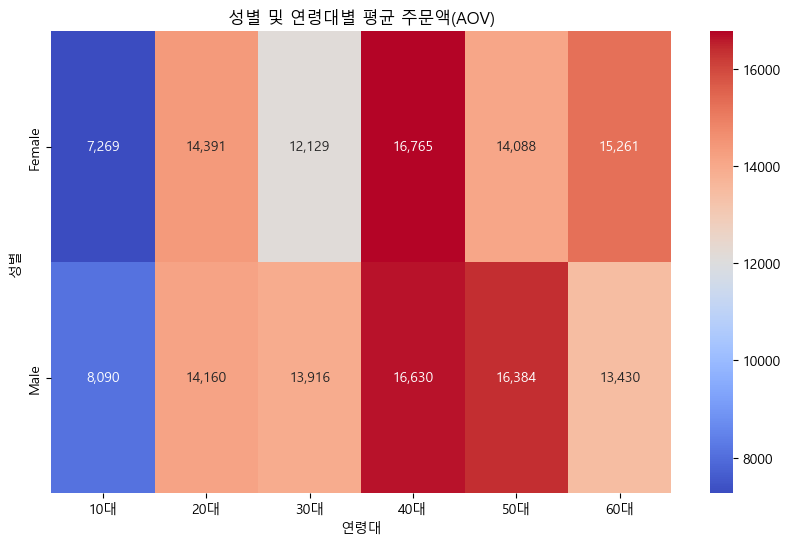

In [3]:
# 성별과 연령대를 조합하여 (예: '20대 남성'), 각 그룹의 평균 주문액(AOV)을 비교해서 히트맵으로
# AOV = 총 매출액 / 총 주문 건수
# 필요한 데이터 - 성별, 나이, 총구매액, 주문건수
# df.columns
quest_cols = ['order_id', 'gender', 'age', 'total_sales', 'quantity'] # 'total_sales'했더니 수치가 많이 차이가 난다!
# 연령대는 60대이상을 60대로까지 만 계산
# df_quest24 = (df[quest_cols].copy()
          # .assign(age_group=lambda x: 
          # (((x['age'] // 10) * 10).clip(upper=60)).astype(str) + '대')               
          
# 연령대에서 70세 이하만 가져오기 
df_quest24 = (
          df[df['age'] < 70][quest_cols].copy()  # 70세 이상 제거
          .assign(age_group=lambda x: ((x['age'] // 10) * 10).astype(str) + '대')               
)   
# print(df_quest24.head(50))
# print(f"행 수: {len(df_quest24)}")

# 성별과 연령대별 평균 주문액(AOV) 계산
aov_result = (df_quest24.groupby(['age_group', 'gender'])
              .agg(
                  total_revenue = ('total_sales', 'sum'),    # 총 매출
                  #    order_counts  = ('quantity', 'sum')       # 주문 수량
                  # order_counts  = ('order_id', 'count')       # 주문 건수
              )
            #   .assign(aov=lambda x: x['total_revenue'] / x['order_counts'])  # AOV 계산
              .assign(aov=lambda x: x['total_revenue'] / len(df_quest24))  # AOV 계산
              .reset_index()
             )
print(aov_result)

   age_group  gender  total_revenue           aov
0        10대  Female       72692800   7383.727781
1        10대    Male       80895200   8216.881666
2        20대  Female      143908000  14617.369223
3        20대    Male      141604100  14383.351955
4        30대  Female      121292200  12320.182834
5        30대    Male      139158300  14134.921280
6        40대  Female      167651300  17029.080752
7        40대    Male      166302300  16892.056882
8        50대  Female      140882000  14310.005079
9        50대    Male      163837500  16641.696293
10       60대  Female      152606000  15500.863382
11       60대    Male      134302600  13641.706450


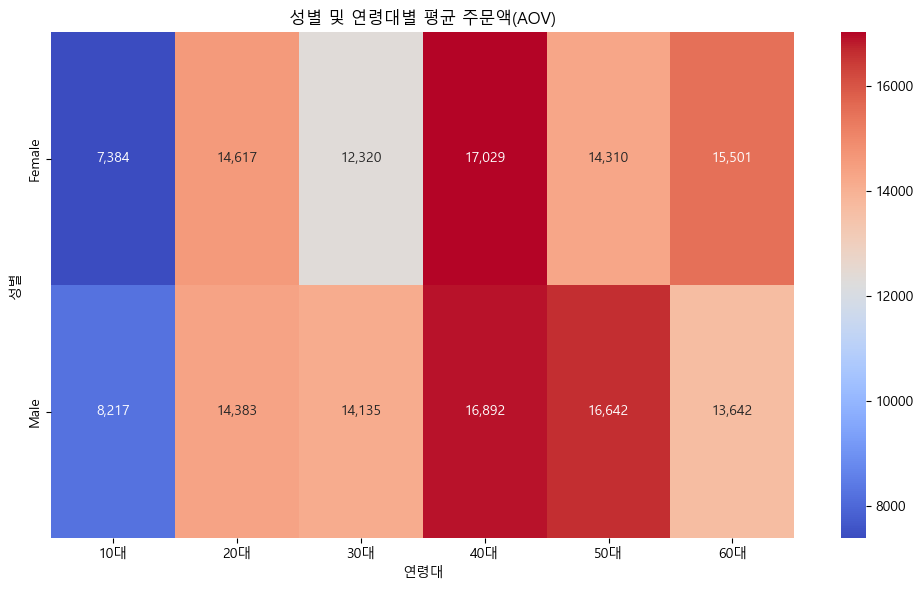

In [ ]:
# 피벗 테이블로 변환 (히트맵용)
pivot_aov = aov_result.pivot_table(
    index='gender',
    columns='age_group',
    values='aov'
)

# 히트맵 그리기
plt.figure(figsize=(10, 6))
annot_data = pivot_aov.map(lambda x: f'{x:,.0f}')
sns.heatmap(pivot_aov, annot=annot_data, fmt='', cmap='coolwarm') 
plt.title('성별 및 연령대별 평균 주문액(AOV)')
plt.xlabel('연령대')
plt.ylabel('성별')
plt.tight_layout()
plt.show()